# Tuning des Hyperparamètres — Flood Prediction
**Projet ML — Académie des Mathématiques Appliquées (AMA)**  
Phase 9 : Optimisation des modèles avec GridSearchCV

## 1. Importation & Préparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# Chargement
df = pd.read_csv('train.csv')
features = [c for c in df.columns if c not in ['id', 'FloodProbability']]
X = df[features]
y = df['FloodProbability']

# Split principal (dataset complet)
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Sous-ensemble pour GridSearch (plus rapide)
# GridSearch teste de nombreuses combinaisons — on utilise 50 000 lignes
X_sample = X.sample(n=50000, random_state=42)
y_sample = y[X_sample.index]
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42
)

print(f' Données prêtes')
print(f'   Dataset complet : {X_train_full.shape[0]:,} lignes (entraînement final)')
print(f'   Sous-ensemble   : {X_train_s.shape[0]:,} lignes (recherche des hyperparamètres)')

 Données prêtes
   Dataset complet : 894,365 lignes (entraînement final)
   Sous-ensemble   : 40,000 lignes (recherche des hyperparamètres)


## 2. Tuning de Ridge — l'hyperparamètre `alpha`

**`alpha`** contrôle la force de la pénalisation :
- `alpha` très petit (ex: 0.001) → presque pas de pénalité → modèle très libre
- `alpha` grand (ex: 1000) → forte pénalité → coefficients très petits → modèle rigide

On teste 7 valeurs différentes avec une **validation croisée 5-Fold** sur chacune.

In [3]:
print(' Recherche du meilleur alpha pour Ridge...')
print('   (Teste 7 valeurs × 5 folds = 35 entraînements)')
print()

param_grid_ridge = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
}

gs_ridge = GridSearchCV(
    Ridge(),
    param_grid_ridge,
    cv=5,           # 5-Fold cross-validation
    scoring='r2',   # On optimise le R²
    n_jobs=-1       # Utilise tous les cœurs du CPU
)

t0 = time.time()
gs_ridge.fit(X_train_s, y_train_s)

print(f' Terminé en {time.time()-t0:.1f}s')
print(f' Meilleur alpha : {gs_ridge.best_params_["alpha"]}')
print(f'   R² moyen (CV) : {gs_ridge.best_score_:.4f}')

 Recherche du meilleur alpha pour Ridge...
   (Teste 7 valeurs × 5 folds = 35 entraînements)

 Terminé en 0.6s
 Meilleur alpha : 10.0
   R² moyen (CV) : 0.8467


   Alpha  R² moyen  Écart-type
   0.001    0.8467      0.0011
   0.010    0.8467      0.0011
   0.100    0.8467      0.0011
   1.000    0.8467      0.0011
  10.000    0.8467      0.0011
 100.000    0.8467      0.0011
1000.000    0.8466      0.0010


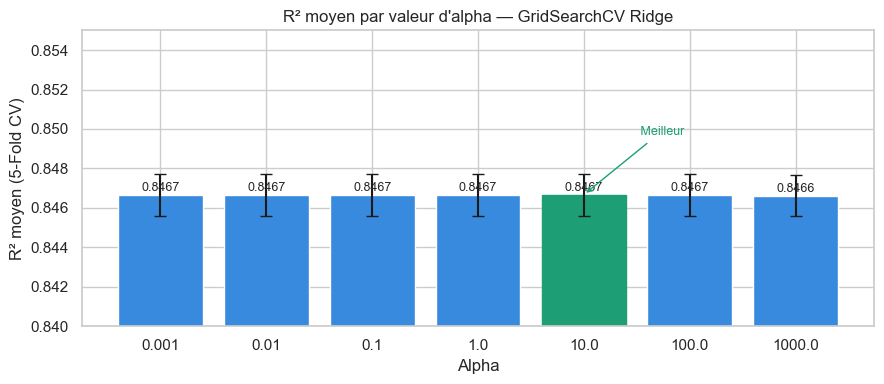

In [4]:
# Résultats détaillés de chaque valeur d'alpha testée
results_ridge = pd.DataFrame(gs_ridge.cv_results_)[['param_alpha','mean_test_score','std_test_score']]
results_ridge.columns = ['Alpha', 'R² moyen', 'Écart-type']
results_ridge = results_ridge.round(4)
print(results_ridge.to_string(index=False))

# Graphique
fig, ax = plt.subplots(figsize=(9, 4))
alphas = [str(a) for a in param_grid_ridge['alpha']]
scores = gs_ridge.cv_results_['mean_test_score']
stds   = gs_ridge.cv_results_['std_test_score']

bars = ax.bar(alphas, scores, color='#378ADD', edgecolor='white', yerr=stds, capsize=4)
best_idx = list(param_grid_ridge['alpha']).index(gs_ridge.best_params_['alpha'])
bars[best_idx].set_color('#1D9E75')  # Colore le meilleur en vert

ax.set_title('R² moyen par valeur d\'alpha — GridSearchCV Ridge')
ax.set_xlabel('Alpha')
ax.set_ylabel('R² moyen (5-Fold CV)')
ax.set_ylim(0.84, 0.855)
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
            f'{score:.4f}', ha='center', fontsize=9)

ax.annotate(' Meilleur', xy=(best_idx, scores[best_idx]),
            xytext=(best_idx + 0.5, scores[best_idx] + 0.003),
            fontsize=9, color='#1D9E75',
            arrowprops=dict(arrowstyle='->', color='#1D9E75'))

plt.tight_layout()
plt.savefig('plot_ridge_gridsearch.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Tuning de Lasso — l'hyperparamètre `alpha`


In [5]:
print(' Recherche du meilleur alpha pour Lasso...')

param_grid_lasso = {
    'alpha': [0.00001, 0.0001, 0.001, 0.01, 0.1, 1.0]
}

gs_lasso = GridSearchCV(
    Lasso(max_iter=10000),
    param_grid_lasso,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

t0 = time.time()
gs_lasso.fit(X_train_s, y_train_s)

print(f' Terminé en {time.time()-t0:.1f}s')
print(f' Meilleur alpha : {gs_lasso.best_params_["alpha"]}')
print(f'   R² moyen (CV) : {gs_lasso.best_score_:.4f}')

# Vérifier combien de variables Lasso met à zéro
best_lasso = gs_lasso.best_estimator_
n_zeros = (best_lasso.coef_ == 0).sum()
print(f'   Variables éliminées (coef=0) : {n_zeros} / {len(features)}')

 Recherche du meilleur alpha pour Lasso...
 Terminé en 0.7s
 Meilleur alpha : 1e-05
   R² moyen (CV) : 0.8467
   Variables éliminées (coef=0) : 0 / 20


## 4. Tuning du Gradient Boosting — plusieurs hyperparamètres

In [6]:
print(' Recherche des meilleurs paramètres pour GBM...')
print('   (2 × 3 × 3 = 18 combinaisons × 3 folds = 54 entraînements)')
print('    Patience, cela peut prendre 3-5 minutes...')
print()

param_grid_gbm = {
    'n_estimators' : [50, 100],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth'    : [3, 4, 5]
}

gs_gbm = GridSearchCV(
    GradientBoostingRegressor(random_state=42, subsample=0.8),
    param_grid_gbm,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

t0 = time.time()
gs_gbm.fit(X_train_s, y_train_s)

print(f'\n Terminé en {time.time()-t0:.1f}s')
print(f'🏆 Meilleurs paramètres : {gs_gbm.best_params_}')
print(f'   R² moyen (CV)       : {gs_gbm.best_score_:.4f}')

🔍 Recherche des meilleurs paramètres pour GBM...
   (2 × 3 × 3 = 18 combinaisons × 3 folds = 54 entraînements)
   ⏳ Patience, cela peut prendre 3-5 minutes...

Fitting 3 folds for each of 18 candidates, totalling 54 fits

✅ Terminé en 84.2s
🏆 Meilleurs paramètres : {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100}
   R² moyen (CV)       : 0.7795


In [7]:
# Top 5 combinaisons GBM
res_gbm = pd.DataFrame(gs_gbm.cv_results_)
top5 = res_gbm.nlargest(5, 'mean_test_score')[
    ['param_n_estimators','param_learning_rate','param_max_depth','mean_test_score','std_test_score']
].round(4)
top5.columns = ['n_estimators','learning_rate','max_depth','R² moyen','Écart-type']
print('Top 5 combinaisons :')
print(top5.to_string(index=False))

Top 5 combinaisons :
 n_estimators  learning_rate  max_depth  R² moyen  Écart-type
          100            0.2          5    0.7795      0.0028
          100            0.2          4    0.7727      0.0027
          100            0.2          3    0.7503      0.0032
          100            0.1          5    0.7191      0.0027
           50            0.2          5    0.7088      0.0023


## 5. Comparaison Avant / Après Tuning

=== AVANT vs APRÈS TUNING ===
                                 R²     MAE    RMSE
Ridge (avant)                0.8449  0.0158  0.0201
Ridge (après — alpha=10.0)   0.8449  0.0158  0.0201
Lasso (avant)                0.8449  0.0158  0.0201
Lasso (après — alpha=1e-05)  0.8449  0.0158  0.0201


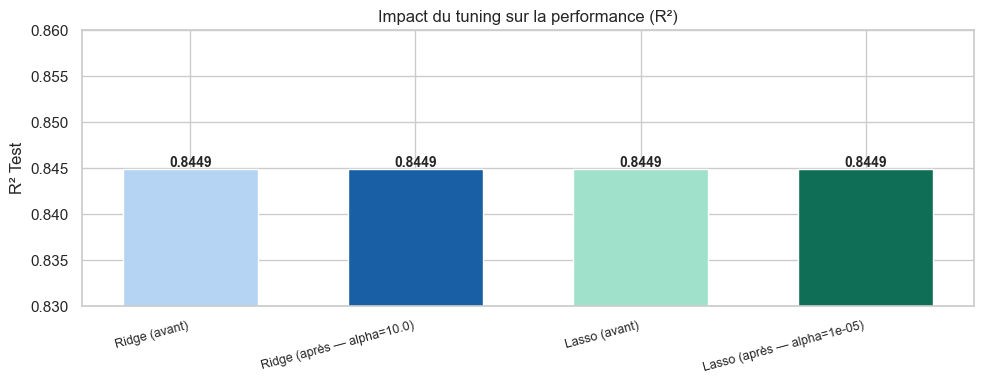

In [8]:
def metriques(y_true, y_pred):
    return {
        'R²'  : round(r2_score(y_true, y_pred), 4),
        'MAE' : round(mean_absolute_error(y_true, y_pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_true, y_pred)), 4)
    }

# --- Ridge avant / après ---
r_avant = Ridge(alpha=1.0).fit(X_train_full, y_train_full)
r_apres = Ridge(alpha=gs_ridge.best_params_['alpha']).fit(X_train_full, y_train_full)

# --- Lasso avant / après ---
l_avant = Lasso(alpha=0.0001).fit(X_train_full, y_train_full)
l_apres = Lasso(alpha=gs_lasso.best_params_['alpha']).fit(X_train_full, y_train_full)

comparaison = {
    'Ridge (avant)' : metriques(y_test_full, r_avant.predict(X_test_full)),
    f'Ridge (après — alpha={gs_ridge.best_params_["alpha"]})': metriques(y_test_full, r_apres.predict(X_test_full)),
    'Lasso (avant)' : metriques(y_test_full, l_avant.predict(X_test_full)),
    f'Lasso (après — alpha={gs_lasso.best_params_["alpha"]})': metriques(y_test_full, l_apres.predict(X_test_full)),
}

df_comp = pd.DataFrame(comparaison).T
print('=== AVANT vs APRÈS TUNING ===')
print(df_comp.to_string())

# Graphique
fig, ax = plt.subplots(figsize=(10, 4))
noms   = list(comparaison.keys())
r2s    = [v['R²'] for v in comparaison.values()]
colors = ['#B5D4F4','#185FA5','#9FE1CB','#0F6E56']

bars = ax.bar(range(len(noms)), r2s, color=colors, edgecolor='white', width=0.6)
ax.set_xticks(range(len(noms)))
ax.set_xticklabels(noms, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('R² Test')
ax.set_title('Impact du tuning sur la performance (R²)')
ax.set_ylim(0.83, 0.86)
for bar, val in zip(bars, r2s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
            f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_avant_apres_tuning.png', dpi=150, bbox_inches='tight')
plt.show()